# Notebook 07 — RFM Analysis and Customer Segmentation

## Purpose
I compute RFM (Recency, Frequency, Monetary) scores for every unique customer
and assign them to named business segments.

## Why this matters
RFM is the industry-standard framework for customer segmentation.  It is
interpretable, proven in practice, and directly actionable — each segment
has a known retention strategy.

## Inputs
`data/processed/master.parquet`

## Outputs
`data/processed/rfm_scores.parquet`

## Key checks
- One row per unique customer
- Score bins are well-populated (no empty quintiles)
- Segment distribution is reasonable


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, str(Path('..').resolve()))
from src.config import load_config
from src.paths import Paths
from src.rfm import compute_rfm, score_rfm, assign_segments, full_rfm_pipeline
from src.visualization import (
    plot_rfm_scatter, plot_segment_counts, save_fig
)
from src.utils import save_table

cfg   = load_config()
paths = Paths(cfg)

master = pd.read_parquet(paths.processed / cfg['data']['master_file'])
print(f"Master loaded: {master.shape}")
print(f"Unique customers: {master['customer_unique_id'].nunique():,}")


Master loaded: (96478, 33)
Unique customers: 93,358


In [2]:
# Step 1: Compute raw RFM values
rfm = compute_rfm(master)
print(f"RFM table shape: {rfm.shape}")
print()
print(rfm.describe()[['recency', 'frequency', 'monetary']].round(2))


RFM table shape: (93358, 6)

        recency  frequency  monetary
count  93358.00   93358.00  93358.00
mean     237.94       1.03    141.62
min        1.00       1.00      0.85
25%      114.00       1.00     47.65
50%      219.00       1.00     89.73
75%      346.00       1.00    154.74
max      714.00      15.00  13440.00
std      152.59       0.21    215.69


In [3]:
# Step 2: Score and assign segments
rfm = score_rfm(rfm, n_bins=cfg['rfm']['n_score_bins'])
rfm = assign_segments(rfm)
print()
print("Score distributions:")
for col in ['R', 'F', 'M']:
    print(f"  {col}: {rfm[col].value_counts().sort_index().to_dict()}")



Score distributions:
  R: {1: 18672, 2: 18671, 3: 18672, 4: 18671, 5: 18672}
  F: {1: 18672, 2: 18671, 3: 18672, 4: 18671, 5: 18672}
  M: {1: 18672, 2: 18671, 3: 18672, 4: 18671, 5: 18672}


In [4]:
# Step 3: Inspect segment breakdown
print("=== Segment distribution ===")
seg_counts = rfm['segment'].value_counts()
total = len(rfm)
for seg, n in seg_counts.items():
    print(f"  {seg:<25} {n:>6,}  ({n/total*100:.1f}%)")


=== Segment distribution ===
  At Risk                   15,490  (16.6%)
  Other                     14,684  (15.7%)
  Hibernating               10,566  (11.3%)
  Potential Loyalist         8,222  (8.8%)
  Loyal                      8,153  (8.7%)
  Promising                  6,679  (7.2%)
  Champions                  6,474  (6.9%)
  Cant Lose Them             5,874  (6.3%)
  Need Attention             5,762  (6.2%)
  Lost                       4,666  (5.0%)
  About to Sleep             3,702  (4.0%)
  New Customer               3,086  (3.3%)


In [5]:
# Step 4: Segment revenue analysis — join RFM back to master
rfm_master = rfm.merge(
    master.groupby('customer_unique_id')['order_value'].sum().reset_index(),
    on='customer_unique_id', how='left'
)
# Rename to avoid confusion with rfm['monetary'] which is the same thing
# but let's compute revenue share
rfm_master['revenue_share'] = (
    rfm_master['monetary'] / rfm_master['monetary'].sum() * 100
)
seg_revenue = (
    rfm_master.groupby('segment')
    .agg(
        n_customers=('customer_unique_id', 'count'),
        total_revenue=('monetary', 'sum'),
        avg_recency=('recency', 'mean'),
        avg_frequency=('frequency', 'mean'),
    )
    .round(2)
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)
seg_revenue['revenue_pct'] = (
    seg_revenue['total_revenue'] / seg_revenue['total_revenue'].sum() * 100
).round(2)
print("=== Segment Revenue Summary ===")
print(seg_revenue.to_string(index=False))
save_table(seg_revenue, 'rfm_segment_summary',
           reports_dir=str(paths.reports_tabs),
           paper_dir=str(paths.paper_tabs))


=== Segment Revenue Summary ===
           segment  n_customers  total_revenue  avg_recency  avg_frequency  revenue_pct
           At Risk        15490     3127833.08       380.98           1.05        23.66
             Other        14684     2100187.63       142.45           1.02        15.88
         Champions         6474     1774913.54        90.89           1.17        13.42
    Cant Lose Them         5874     1411442.64       436.15           1.06        10.68
         Promising         6679     1368948.91       134.06           1.00        10.35
    Need Attention         5762     1097741.57       155.79           1.00         8.30
             Loyal         8153     1038686.00       183.63           1.08         7.86
       Hibernating        10566      568045.66       337.37           1.00         4.30
Potential Loyalist         8222      333220.25        76.66           1.00         2.52
    About to Sleep         3702      159438.22       256.53           1.00         1.21


[WindowsPath('C:/Users/Peter/Documents/projects/Jobberman_projects/double_Integral/ecommerce_customer_intelligence/reports/tables/rfm_segment_summary.csv'),
 WindowsPath('C:/Users/Peter/Documents/projects/Jobberman_projects/double_Integral/ecommerce_customer_intelligence/paper_or_report/tables/rfm_segment_summary.csv')]

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\segment_counts.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\segment_counts.png


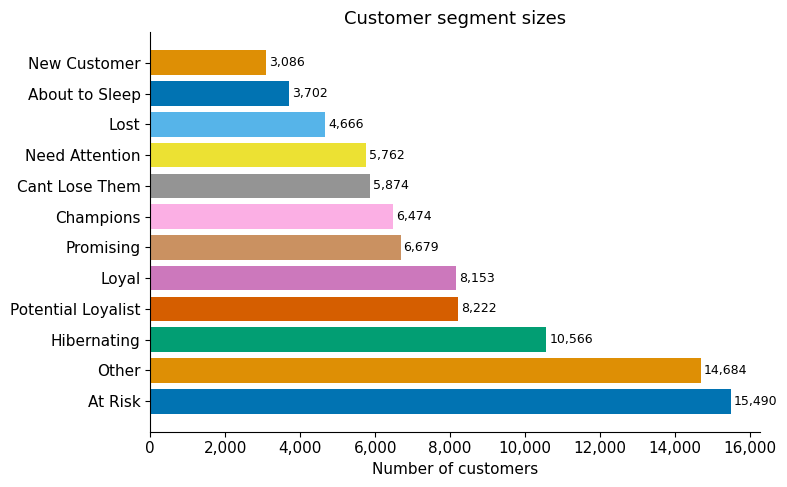

  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\reports\figures\rfm_scatter.png
  Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\paper_or_report\figures\rfm_scatter.png


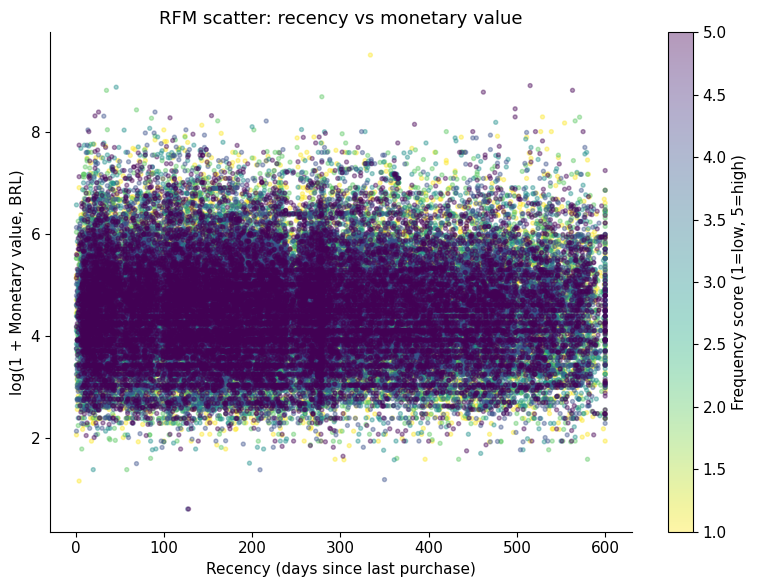

In [6]:
# Step 5: Charts
fig = plot_segment_counts(rfm,
    reports_dir=str(paths.reports_figs),
    paper_dir=str(paths.paper_figs))
plt.show()
plt.close()

fig = plot_rfm_scatter(rfm,
    reports_dir=str(paths.reports_figs),
    paper_dir=str(paths.paper_figs))
plt.show()
plt.close()


In [7]:
# Step 6: Save rfm_scores.parquet
rfm_path = paths.processed / cfg['data']['rfm_file']
rfm.to_parquet(rfm_path, index=False)
print(f"Saved: {rfm_path}")
print(f"Shape: {rfm.shape}")
print()

# Test H1: Do Champions + Loyal account for > 60% of revenue?
top_segs = ['Champions', 'Loyal']
top_rev_pct = seg_revenue[seg_revenue['segment'].isin(top_segs)]['revenue_pct'].sum()
top_cust_pct = (
    seg_revenue[seg_revenue['segment'].isin(top_segs)]['n_customers'].sum() /
    seg_revenue['n_customers'].sum() * 100
)
print(f"H1 test: Champions + Loyal account for {top_rev_pct:.1f}% of revenue")
print(f"         from {top_cust_pct:.1f}% of customers")
result = "SUPPORTED" if top_rev_pct > 50 else "NOT SUPPORTED"
print(f"         H1 is: {result} (cautiously — this is descriptive only)")


Saved: C:\Users\Peter\Documents\projects\Jobberman_projects\double_Integral\ecommerce_customer_intelligence\data\processed\rfm_scores.parquet
Shape: (93358, 11)

H1 test: Champions + Loyal account for 21.3% of revenue
         from 15.7% of customers
         H1 is: NOT SUPPORTED (cautiously — this is descriptive only)
